In [1]:
import numpy as np
import matplotlib.pyplot as plt
from classy import Class
from matplotlib.ticker import LogLocator, NullFormatter

In [2]:
# ============================================================
# Global options
# ============================================================

flag_save_plot = True
temperature_mode = "full_lensed"
lmax = 3000


## SET MODEL

In [3]:
# ============================================================
# Base cosmology
# ============================================================

base = {
    '100*theta_s': 1.04077,
    'omega_b': 0.02225,
    'omega_cdm': 0.1198,
    'tau_reio': 0.0790,
    'ln10^{10}A_s': 3.094,
    'n_s': 0.9645,

    'output': 'tCl,mPk,lCl',
    'lensing': 'yes',
    'P_k_max_1/Mpc': 5.0,
    'l_max_scalars': lmax,
}

In [4]:
# ============================================================
# Helper: CLASS run
# ============================================================

def compute_model(
    base_params,
    k_for_pk,
    monopole_params=None,
    gauge="synchronous",
    temperature_mode="full_lensed",
    lmax=3000,
    early_late_isw_redshift=50,
):
    """
    Compute C_ell and P(k).

    If monopole_params is None:
        run pure LCDM.

    If monopole_params is given:
        run LCDM + monopoles.

    Important:
        omega_cdm is NOT rescaled here.
        Monopole model uses exactly the same omega_cdm as LCDM.
    """

    allowed_modes = {"full_lensed", "full_raw", "tsw", "eisw", "lisw", "dop", "pol"}
    if temperature_mode not in allowed_modes:
        raise ValueError(
            f"Unknown temperature_mode='{temperature_mode}'. "
            f"Allowed modes are: {sorted(allowed_modes)}"
        )

    C = Class()

    settings = dict(base_params)
    settings["gauge"] = gauge

    if monopole_params is not None:
        settings.update(monopole_params)

    if temperature_mode in {"tsw", "eisw", "lisw", "dop", "pol"}:
        settings.update({
            "lensing": "no",
            "temperature contributions": temperature_mode,
            "early_late_isw_redshift": early_late_isw_redshift,
        })

    elif temperature_mode == "full_raw":
        settings["lensing"] = "no"

    elif temperature_mode == "full_lensed":
        settings["lensing"] = "yes"

    C.set(settings)
    C.compute()

    if temperature_mode == "full_lensed":
        cl = C.lensed_cl(lmax)
    else:
        cl = C.raw_cl(lmax)

    pk = np.array([C.pk(k, 0.0) for k in k_for_pk])

    derived = {}
    try:
        derived = C.get_current_derived_parameters(
            ['H0', '100*theta_s', 'z_rec', 'tau_reio']
        )
    except Exception:
        pass

    H0 = C.h() * 100.0
    S8 = C.sigma8() * np.sqrt(C.Omega_m() / 0.3)

    C.struct_cleanup()
    C.empty()

    return cl, pk, H0, S8, derived


def Dl_TT_uK2_from_cl(cl, Tcmb=2.7255):
    """
    Convert CLASS tt spectrum to D_ell in microK^2.

    CLASS returns C_ell^{TT} for (Delta T / T)^2.
    Therefore we multiply by Tcmb^2 and by 1e12.
    """

    ell = cl["ell"]
    Ctt = cl["tt"]

    Dl = ell * (ell + 1.0) * Ctt / (2.0 * np.pi)
    Dl *= Tcmb**2 * 1e12

    return ell, Dl

In [5]:
# ============================================================
# k-grid
# ============================================================

k_for_pk = np.logspace(-3, np.log10(3.0), 300)


In [6]:
# ============================================================
# LCDM reference
# ============================================================

CLtt_lcdm, Pk_lcdm, H0_lcdm, S8_lcdm, drv_lcdm = compute_model(
    base_params=base,
    k_for_pk=k_for_pk,
    monopole_params=None,
    gauge="synchronous",
    temperature_mode=temperature_mode,
    lmax=lmax,
)

print("LCDM")
print("H0 =", H0_lcdm)
print("S8 =", S8_lcdm)
print("100*theta_s =", drv_lcdm.get("100*theta_s", "n/a"))
print()


LCDM
H0 = 67.45660167749372
S8 = 0.8605398418632336
100*theta_s = 1.0407695384991391



## Monopole models

In [7]:
a_t = 1.0 / (40.0 + 1.0)
f_mon = 0.05

cases = [
    {
        "label": r"$\kappa=100$",
        "color": "#0072B2",
        "ls": "-",
        "params": {
            "f_mon": f_mon,
            "kappa_mon": 10.0,
            "a_t_mon": a_t,
        },
    },
    {
        "label": r"$\kappa=7.3077$",
        "color": "#D55E00",
        "ls": "--",
        "params": {
            "f_mon": f_mon,
            "kappa_mon": 7.3077,
            "a_t_mon": a_t,
        },
    },
]

models = []

for case in cases:
    cl, pk, H0, S8, drv = compute_model(
        base_params=base,
        k_for_pk=k_for_pk,
        monopole_params=case["params"],
        gauge="synchronous",
        temperature_mode=temperature_mode,
        lmax=lmax,
    )

    models.append({
        "label": case["label"],
        "color": case["color"],
        "ls": case["ls"],
        "params": case["params"],
        "cl": cl,
        "pk": pk,
        "H0": H0,
        "S8": S8,
        "derived": drv,
    })

    print(case["label"])
    print("params =", case["params"])
    print("H0 =", H0)
    print("S8 =", S8)
    print("100*theta_s =", drv.get("100*theta_s", "n/a"))
    print()


$\kappa=100$
params = {'f_mon': 0.05, 'kappa_mon': 10.0, 'a_t_mon': 0.024390243902439025}
H0 = 69.15858115404023
S8 = 0.8487559618446952
100*theta_s = 1.0407699576393534

$\kappa=7.3077$
params = {'f_mon': 0.05, 'kappa_mon': 7.3077, 'a_t_mon': 0.024390243902439025}
H0 = 69.15304770068921
S8 = 0.848823474104516
100*theta_s = 1.0407699656881586



## Plot: TT comparison

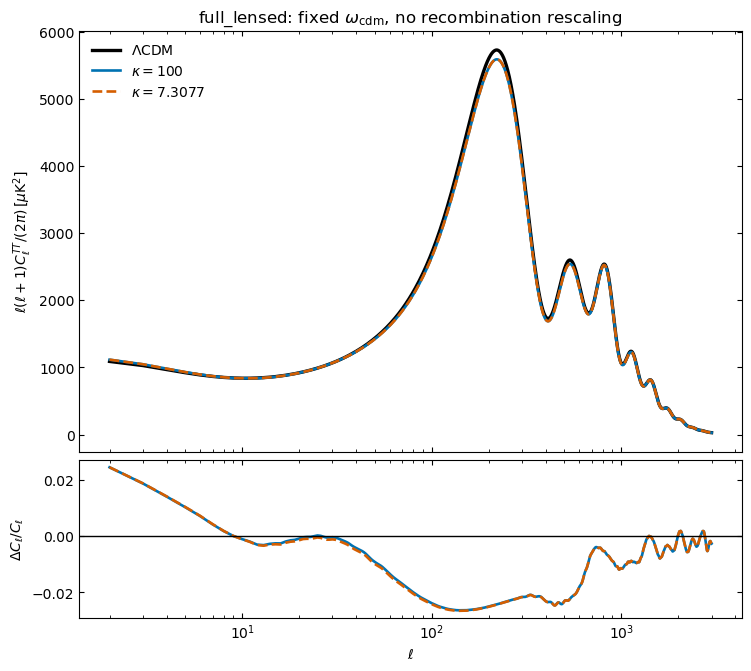

In [8]:
ell_lcdm, Dl_lcdm = Dl_TT_uK2_from_cl(CLtt_lcdm)

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(7.4, 6.6),
    sharex=True,
    gridspec_kw={"height_ratios": [3.2, 1.2]},
    constrained_layout=True,
)

ell_plot_min = 2

# ------------------------------------------------------------
# Top panel: D_ell
# ------------------------------------------------------------

ax1.plot(
    ell_lcdm[ell_plot_min:],
    Dl_lcdm[ell_plot_min:],
    color="black",
    lw=2.4,
    label=r"$\Lambda$CDM",
)

for m in models:
    ell, Dl = Dl_TT_uK2_from_cl(m["cl"])

    ax1.plot(
        ell[ell_plot_min:],
        Dl[ell_plot_min:],
        color=m["color"],
        ls=m["ls"],
        lw=1.9,
        label=m["label"],
    )

ax1.set_xscale("log")
ax1.set_ylabel(r"$\ell(\ell+1)C_\ell^{TT}/(2\pi)\,[\mu{\rm K}^2]$")
ax1.set_title(rf"{temperature_mode}: fixed $\omega_{{\rm cdm}}$, no recombination rescaling")
ax1.tick_params(which="both", direction="in", top=True, right=True)
ax1.legend(frameon=False, fontsize=10, loc="upper left")


# ------------------------------------------------------------
# Bottom panel: fractional difference
# ------------------------------------------------------------

ell_ref = CLtt_lcdm["ell"]
Ctt_ref = CLtt_lcdm["tt"]

eps = 1e-30

for m in models:
    ell = m["cl"]["ell"]
    Ctt = m["cl"]["tt"]

    if not np.array_equal(ell, ell_ref):
        Ctt = np.interp(ell_ref, ell, Ctt)
        ell = ell_ref

    valid = (
        np.isfinite(Ctt_ref)
        & np.isfinite(Ctt)
        & (np.abs(Ctt_ref) > eps)
        & (ell >= ell_plot_min)
    )

    frac = np.full_like(Ctt_ref, np.nan)
    frac[valid] = (Ctt[valid] - Ctt_ref[valid]) / Ctt_ref[valid]

    ax2.plot(
        ell[valid],
        frac[valid],
        color=m["color"],
        ls=m["ls"],
        lw=1.9,
    )

ax2.axhline(0.0, color="black", lw=1.0)

ax2.set_xscale("log")
ax2.set_xlabel(r"$\ell$")
ax2.set_ylabel(r"$\Delta C_\ell/C_\ell$")
ax2.tick_params(which="both", direction="in", top=True, right=True)

if flag_save_plot:
    plt.savefig(f"{temperature_mode}_LCDM_vs_monopoles_fixed_omegacdm.pdf")
else:
    plt.show()

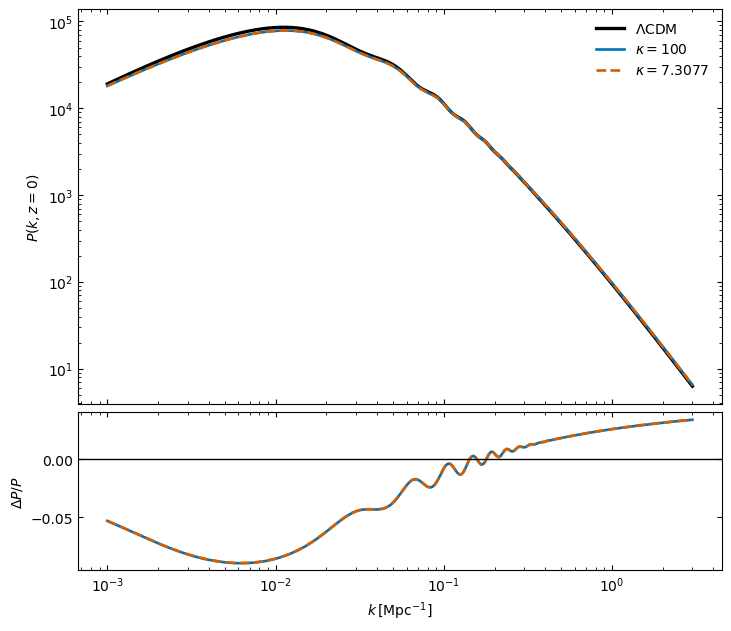

In [9]:
# ============================================================
# Optional: P(k) comparison
# ============================================================

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(7.2, 6.2),
    sharex=True,
    gridspec_kw={"height_ratios": [3.0, 1.2]},
    constrained_layout=True,
)

ax1.plot(
    k_for_pk,
    Pk_lcdm,
    color="black",
    lw=2.4,
    label=r"$\Lambda$CDM",
)

for m in models:
    ax1.plot(
        k_for_pk,
        m["pk"],
        color=m["color"],
        ls=m["ls"],
        lw=1.9,
        label=m["label"],
    )

ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_ylabel(r"$P(k,z=0)$")
ax1.tick_params(which="both", direction="in", top=True, right=True)
ax1.legend(frameon=False, fontsize=10)

for m in models:
    frac_pk = (m["pk"] - Pk_lcdm) / Pk_lcdm

    ax2.plot(
        k_for_pk,
        frac_pk,
        color=m["color"],
        ls=m["ls"],
        lw=1.9,
    )

ax2.axhline(0.0, color="black", lw=1.0)
ax2.set_xscale("log")
ax2.set_xlabel(r"$k\,[{\rm Mpc}^{-1}]$")
ax2.set_ylabel(r"$\Delta P/P$")
ax2.tick_params(which="both", direction="in", top=True, right=True)

if flag_save_plot:
    plt.savefig("Pk_LCDM_vs_monopoles_fixed_omegacdm.pdf")
else:
    plt.show()


## Gauge test: synchronous vs Newtonian

Gauge test for monopole model
H0 synchronous = 69.16493604788616
H0 newtonian   = 69.16493604788616
S8 synchronous = 0.8486764132759156
S8 newtonian   = 0.8487111621073763


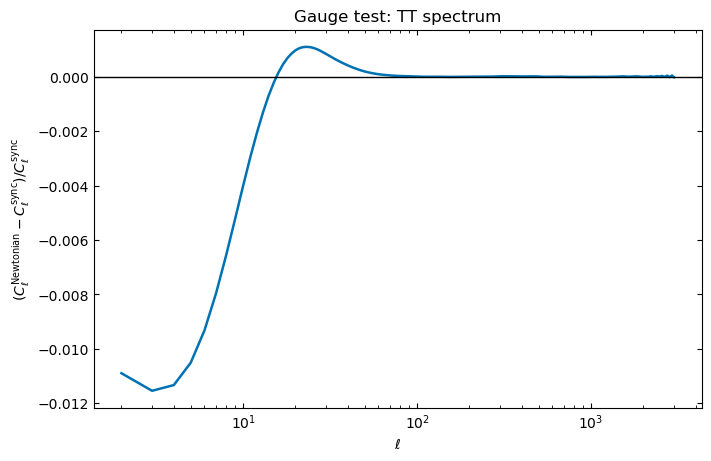

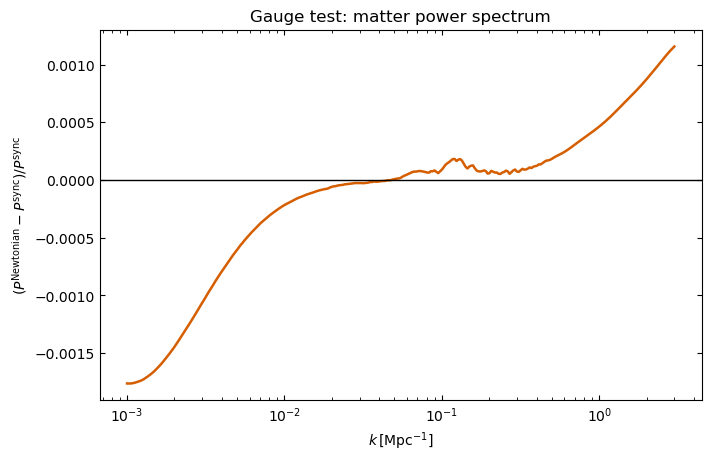

In [17]:
# ============================================================
# Gauge test: synchronous vs Newtonian
# ============================================================

run_gauge_test = True

if run_gauge_test:

    mono_params = {
        "f_mon": f_mon,
        "kappa_mon": 100.0,
        "a_t_mon": a_t,
    }

    cl_sync, pk_sync, H0_sync, S8_sync, _ = compute_model(
        base_params=base,
        k_for_pk=k_for_pk,
        monopole_params=mono_params,
        gauge="synchronous",
        temperature_mode=temperature_mode,
        lmax=lmax,
    )

    cl_newt, pk_newt, H0_newt, S8_newt, _ = compute_model(
        base_params=base,
        k_for_pk=k_for_pk,
        monopole_params=mono_params,
        gauge="newtonian",
        temperature_mode=temperature_mode,
        lmax=lmax,
    )

    ell_sync = cl_sync["ell"]
    Ctt_sync = cl_sync["tt"]

    ell_newt = cl_newt["ell"]
    Ctt_newt = cl_newt["tt"]

    if not np.array_equal(ell_sync, ell_newt):
        Ctt_newt = np.interp(ell_sync, ell_newt, Ctt_newt)

    valid = (
        np.isfinite(Ctt_sync)
        & np.isfinite(Ctt_newt)
        & (np.abs(Ctt_sync) > eps)
        & (ell_sync >= ell_plot_min)
    )

    frac_cl_gauge = np.full_like(Ctt_sync, np.nan)
    frac_cl_gauge[valid] = (Ctt_newt[valid] - Ctt_sync[valid]) / Ctt_sync[valid]

    frac_pk_gauge = (pk_newt - pk_sync) / pk_sync

    print("Gauge test for monopole model")
    print("H0 synchronous =", H0_sync)
    print("H0 newtonian   =", H0_newt)
    print("S8 synchronous =", S8_sync)
    print("S8 newtonian   =", S8_newt)

    # --------------------------------------------------------
    # Gauge test: C_ell
    # --------------------------------------------------------

    fig, ax = plt.subplots(figsize=(7.0, 4.5), constrained_layout=True)

    ax.plot(
        ell_sync[valid],
        frac_cl_gauge[valid],
        color="#0072B2",
        lw=1.8,
    )

    ax.axhline(0.0, color="black", lw=1.0)

    ax.set_xscale("log")
    ax.set_xlabel(r"$\ell$")
    ax.set_ylabel(
        r"$(C_\ell^{\rm Newtonian}-C_\ell^{\rm sync})/C_\ell^{\rm sync}$"
    )
    ax.set_title("Gauge test: TT spectrum")
    ax.tick_params(which="both", direction="in", top=True, right=True)

    if flag_save_plot:
        plt.savefig("gauge_test_TT_synchronous_vs_newtonian.pdf")
    else:
        plt.show()

    # --------------------------------------------------------
    # Gauge test: P(k)
    # --------------------------------------------------------

    fig, ax = plt.subplots(figsize=(7.0, 4.5), constrained_layout=True)

    ax.plot(
        k_for_pk,
        frac_pk_gauge,
        color="#D55E00",
        lw=1.8,
    )

    ax.axhline(0.0, color="black", lw=1.0)

    ax.set_xscale("log")
    ax.set_xlabel(r"$k\,[{\rm Mpc}^{-1}]$")
    ax.set_ylabel(
        r"$(P^{\rm Newtonian}-P^{\rm sync})/P^{\rm sync}$"
    )
    ax.set_title("Gauge test: matter power spectrum")
    ax.tick_params(which="both", direction="in", top=True, right=True)

    if flag_save_plot:
        plt.savefig("gauge_test_Pk_synchronous_vs_newtonian.pdf")
    else:
        plt.show()

In [11]:
try:
    cl_newt, pk_newt, H0_newt, S8_newt, _ = compute_model(
        base_params=base,
        k_for_pk=k_for_pk,
        monopole_params=mono_params,
        gauge="newtonian",
        temperature_mode=temperature_mode,
        lmax=lmax,
    )

    print("Newtonian gauge run succeeded.")

except Exception as err:
    print("Newtonian gauge run failed.")
    print("This likely indicates a numerical/implementation issue in the monopole perturbation equations,")
    print("not necessarily a physical gauge dependence.")
    print()
    print(err)

Newtonian gauge run succeeded.
